# Heart Disease Prediction Model — LightGBM
Dataset: Cleveland Heart Disease (OpenML heart-c)
Task: Binary classification — disease vs no disease

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report
import lightgbm as lgb
import shap
import joblib
import os
MODEL_DIR = '../models'
os.makedirs(MODEL_DIR, exist_ok=True)
print('Setup complete')

Setup complete


In [10]:
data = fetch_openml('heart-c', version=1, as_frame=True, parser='auto')
# Use data.data for features and data.target for labels
df = data.data.copy()
print('Feature columns:', df.columns.tolist())
print('Target name:', data.target.name)
print('Target unique values:', data.target.unique())
print('Shape:', df.shape)
df.head()

Feature columns: ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal']
Target name: num
Target unique values: ['<50', '>50_1']
Categories (2, str): ['<50', '>50_1']
Shape: (303, 13)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
0,63,male,typ_angina,145,233,t,left_vent_hyper,150,no,2.3,down,0.0,fixed_defect
1,67,male,asympt,160,286,f,left_vent_hyper,108,yes,1.5,flat,3.0,normal
2,67,male,asympt,120,229,f,left_vent_hyper,129,yes,2.6,flat,2.0,reversable_defect
3,37,male,non_anginal,130,250,f,normal,187,no,3.5,down,0.0,normal
4,41,female,atyp_angina,130,204,f,left_vent_hyper,172,no,1.4,up,0.0,normal


In [11]:
# Binarize target: '<50' = no disease (0), '>50_1' = disease (1)
# Cell 2 printed the actual unique values so we use them directly
df['target'] = (data.target.astype(str).str.strip() != '<50').astype(int)
print('Class distribution:')
print(df['target'].value_counts())

# Encode categorical columns
for col in df.select_dtypes(include=['category', 'object']).columns:
    if col == 'target':
        continue
    df[col] = pd.Categorical(df[col]).codes.astype(float)
    df[col] = df[col].replace(-1, np.nan)  # -1 from Categorical codes means NaN

# Fill missing values with median
df = df.fillna(df.median(numeric_only=True))

feature_names = [c for c in df.columns if c != 'target']
X = df[feature_names].astype(float).values
y = df['target'].values
print('Features:', feature_names)
print('X shape:', X.shape)
print('Class balance:', y.mean().round(3), 'positive rate')

Class distribution:
target
0    165
1    138
Name: count, dtype: int64
Features: ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal']
X shape: (303, 13)
Class balance: 0.455 positive rate


In [12]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)
print(f'Train: {X_train.shape[0]} | Test: {X_test.shape[0]}')

Train: 242 | Test: 61


In [13]:
model = lgb.LGBMClassifier(
    n_estimators=300, max_depth=5, learning_rate=0.05,
    num_leaves=31, subsample=0.8, colsample_bytree=0.8,
    random_state=42, verbose=-1
)
model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    callbacks=[lgb.early_stopping(30, verbose=False), lgb.log_evaluation(50)]
)
print('Training complete')

[50]	valid_0's binary_logloss: 0.417828
[100]	valid_0's binary_logloss: 0.382916
Training complete


In [14]:
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]
print(f'Accuracy : {accuracy_score(y_test, y_pred):.4f}')
print(f'ROC-AUC  : {roc_auc_score(y_test, y_proba):.4f}')
print()
print(classification_report(y_test, y_pred, target_names=['No Disease', 'Heart Disease']))
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(model, X_scaled, y, cv=cv, scoring='roc_auc')
print(f'5-Fold CV ROC-AUC: {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})')

Accuracy : 0.8361
ROC-AUC  : 0.9145

               precision    recall  f1-score   support

   No Disease       0.83      0.88      0.85        33
Heart Disease       0.85      0.79      0.81        28

     accuracy                           0.84        61
    macro avg       0.84      0.83      0.83        61
 weighted avg       0.84      0.84      0.84        61

5-Fold CV ROC-AUC: 0.8809 (+/- 0.0431)


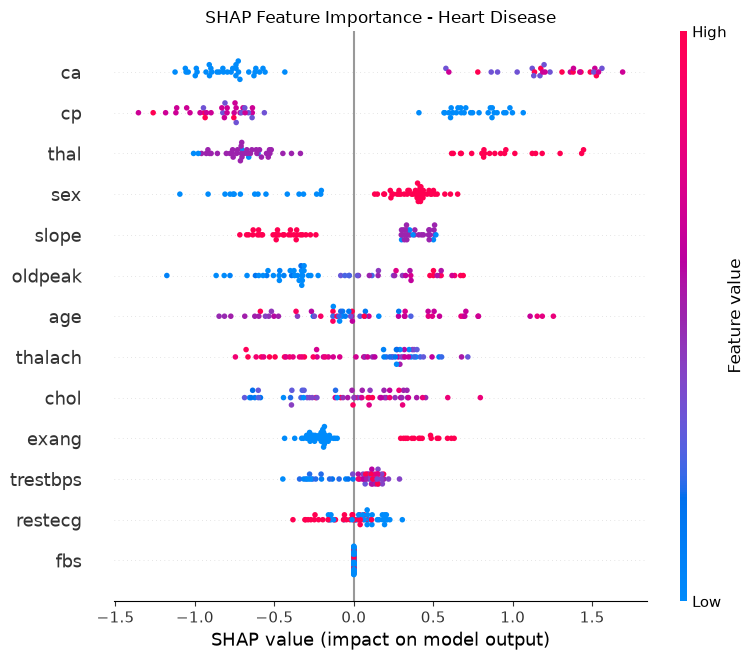

SHAP plot saved


In [15]:
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)
sv = shap_values[1] if isinstance(shap_values, list) else shap_values
plt.figure(figsize=(8, 5))
shap.summary_plot(sv, X_test, feature_names=feature_names, show=False)
plt.title('SHAP Feature Importance - Heart Disease')
plt.tight_layout()
plt.savefig(f'{MODEL_DIR}/heart_shap.png', dpi=150, bbox_inches='tight')
plt.show()
print('SHAP plot saved')

In [16]:
joblib.dump(model,         f'{MODEL_DIR}/heart_model.pkl')
joblib.dump(scaler,        f'{MODEL_DIR}/heart_scaler.pkl')
joblib.dump(feature_names, f'{MODEL_DIR}/heart_features.pkl')
for fname in ['heart_model.pkl', 'heart_scaler.pkl', 'heart_features.pkl']:
    size = os.path.getsize(f'{MODEL_DIR}/{fname}') / 1024
    print(f'  {fname}  ({size:.1f} KB)')
print('All heart artifacts saved!')

  heart_model.pkl  (139.3 KB)
  heart_scaler.pkl  (0.9 KB)
  heart_features.pkl  (0.1 KB)
All heart artifacts saved!
